In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ pandas:", pd.__version__)
print("✅ numpy:", np.__version__)
print("✅ matplotlib:", plt.matplotlib.__version__)
print("✅ seaborn:", sns.__version__)
print("\n🚀 Todo listo para el proyecto")

✅ pandas: 3.0.2
✅ numpy: 2.4.4
✅ matplotlib: 3.10.8
✅ seaborn: 0.13.2

🚀 Todo listo para el proyecto


In [2]:
# Columnas del dataset NASA Turbofan
cols = ['unit', 'cycle', 'setting1', 'setting2', 'setting3'] + \
       [f's{i}' for i in range(1, 22)]

# Carga del dataset
train = pd.read_csv('../data/train_FD001.txt', 
                    sep='\s+', 
                    header=None, 
                    names=cols)

# Eliminamos columnas que no aportan información
train.drop(columns=['setting3', 's16', 's18', 's19'], 
           inplace=True)

print(f"✅ Dataset cargado correctamente")
print(f"📊 Filas: {train.shape[0]:,}")
print(f"📊 Columnas: {train.shape[1]}")
print(f"\nPrimeras 5 filas:")
train.head()

✅ Dataset cargado correctamente
📊 Filas: 20,631
📊 Columnas: 22

Primeras 5 filas:


,unit,cycle,setting1,setting2,s1,s2,s3,s4,s5,s6,...,s9,s10,s11,s12,s13,s14,s15,s17,s20,s21
0,1,1,-0.0007,-0.0004,518.67,641.82,1589.70,1400.60,14.62,21.61,...,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,1,2,0.0019,-0.0003,518.67,642.15,1591.82,1403.14,14.62,21.61,...,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,1,3,-0.0043,0.0003,518.67,642.35,1587.99,1404.20,14.62,21.61,...,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,1,4,0.0007,0.0000,518.67,642.35,1582.79,1401.87,14.62,21.61,...,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,1,5,-0.0019,-0.0002,518.67,642.37,1582.85,1406.22,14.62,21.61,...,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044


In [3]:
# Cuántos motores hay en el dataset
n_units = train['unit'].nunique()
print(f"✅ Total de motores: {n_units}")

# Cuántos ciclos tiene cada motor
cycles_per_unit = train.groupby('unit')['cycle'].max()
print(f"\n📊 Ciclos promedio por motor: {cycles_per_unit.mean():.0f}")
print(f"📊 Motor con más ciclos: {cycles_per_unit.max()}")
print(f"📊 Motor con menos ciclos: {cycles_per_unit.min()}")

# Información general
print("\n📋 Info del dataset:")
train.info()

✅ Total de motores: 100

📊 Ciclos promedio por motor: 206
📊 Motor con más ciclos: 362
📊 Motor con menos ciclos: 128

📋 Info del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   unit      20631 non-null  int64  
 1   cycle     20631 non-null  int64  
 2   setting1  20631 non-null  float64
 3   setting2  20631 non-null  float64
 4   s1        20631 non-null  float64
 5   s2        20631 non-null  float64
 6   s3        20631 non-null  float64
 7   s4        20631 non-null  float64
 8   s5        20631 non-null  float64
 9   s6        20631 non-null  float64
 10  s7        20631 non-null  float64
 11  s8        20631 non-null  float64
 12  s9        20631 non-null  float64
 13  s10       20631 non-null  float64
 14  s11       20631 non-null  float64
 15  s12       20631 non-null  float64
 16  s13       20631 non-null  float64
 17  s14       20631 non

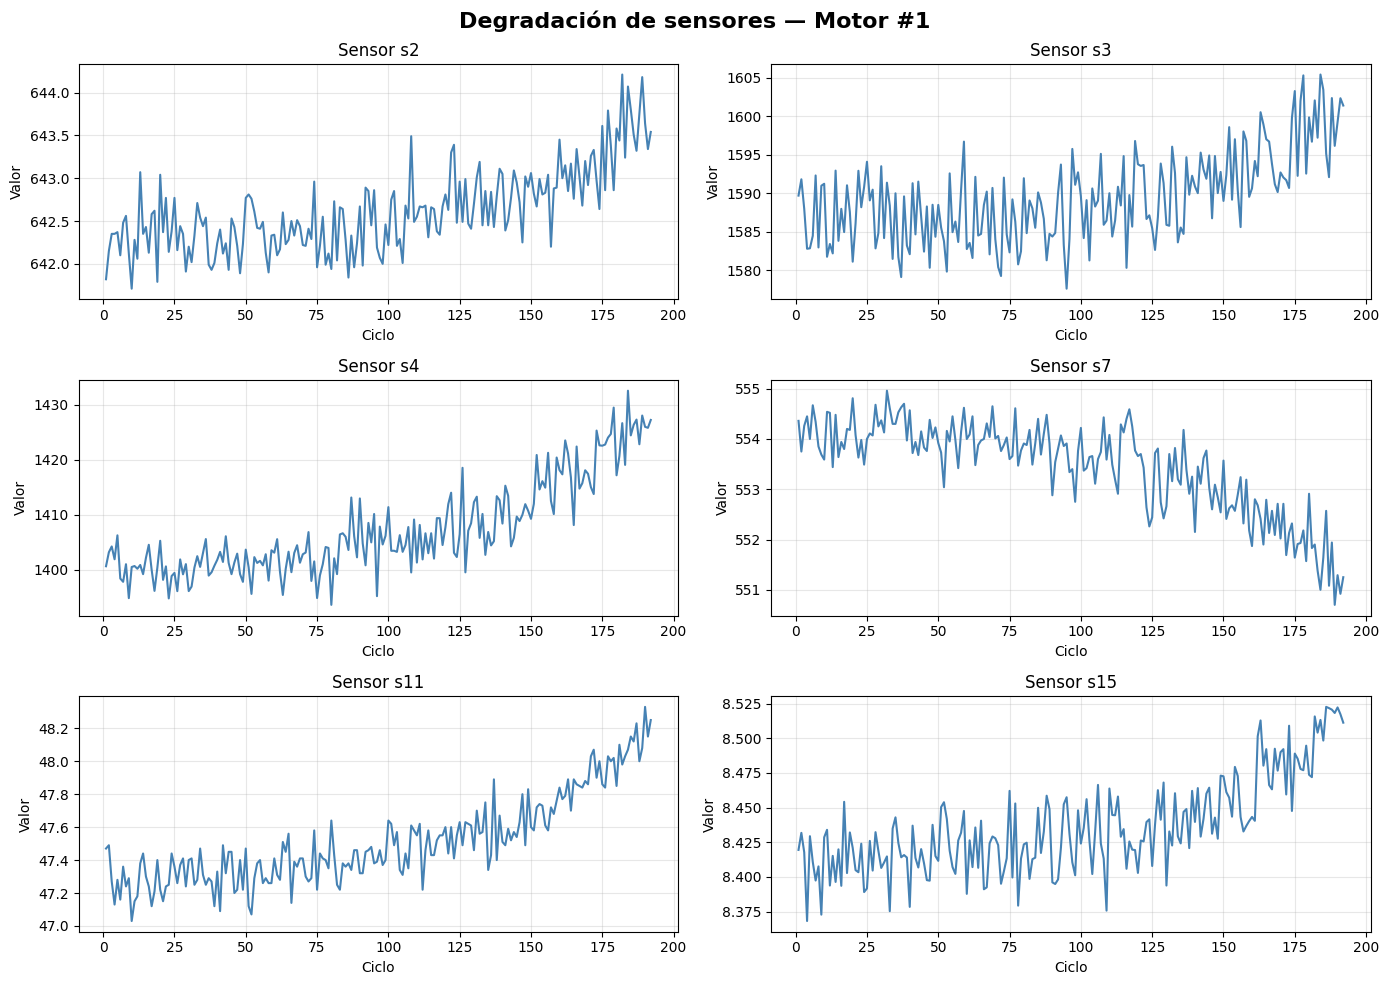

✅ Gráfica guardada en src/


In [4]:
# Visualiza cómo degradan los sensores en un motor
unit_example = train[train['unit'] == 1]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Degradación de sensores — Motor #1', 
             fontsize=16, fontweight='bold')

sensors = ['s2', 's3', 's4', 's7', 's11', 's15']

for ax, sensor in zip(axes.flatten(), sensors):
    ax.plot(unit_example['cycle'], 
            unit_example[sensor], 
            color='steelblue', 
            linewidth=1.5)
    ax.set_title(f'Sensor {sensor}')
    ax.set_xlabel('Ciclo')
    ax.set_ylabel('Valor')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../src/sensor_degradation.png', dpi=150)
plt.show()
print("✅ Gráfica guardada en src/")